#### This notebook contains the cross-maturity assessment in code

This is a simple initial calculation for cross-marutity matrices (does not match the paper)

/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_36959/3584930924.py:38: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hist_monthly = hist_monthly.set_index("DATE").resample("M").last().reset_index()
/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_36959/3584930924.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Historical monthly matrix shape: (11, 11)
Simulated pooled matrix shape:  (11, 11)
L1 norm between matrices: 15.079843


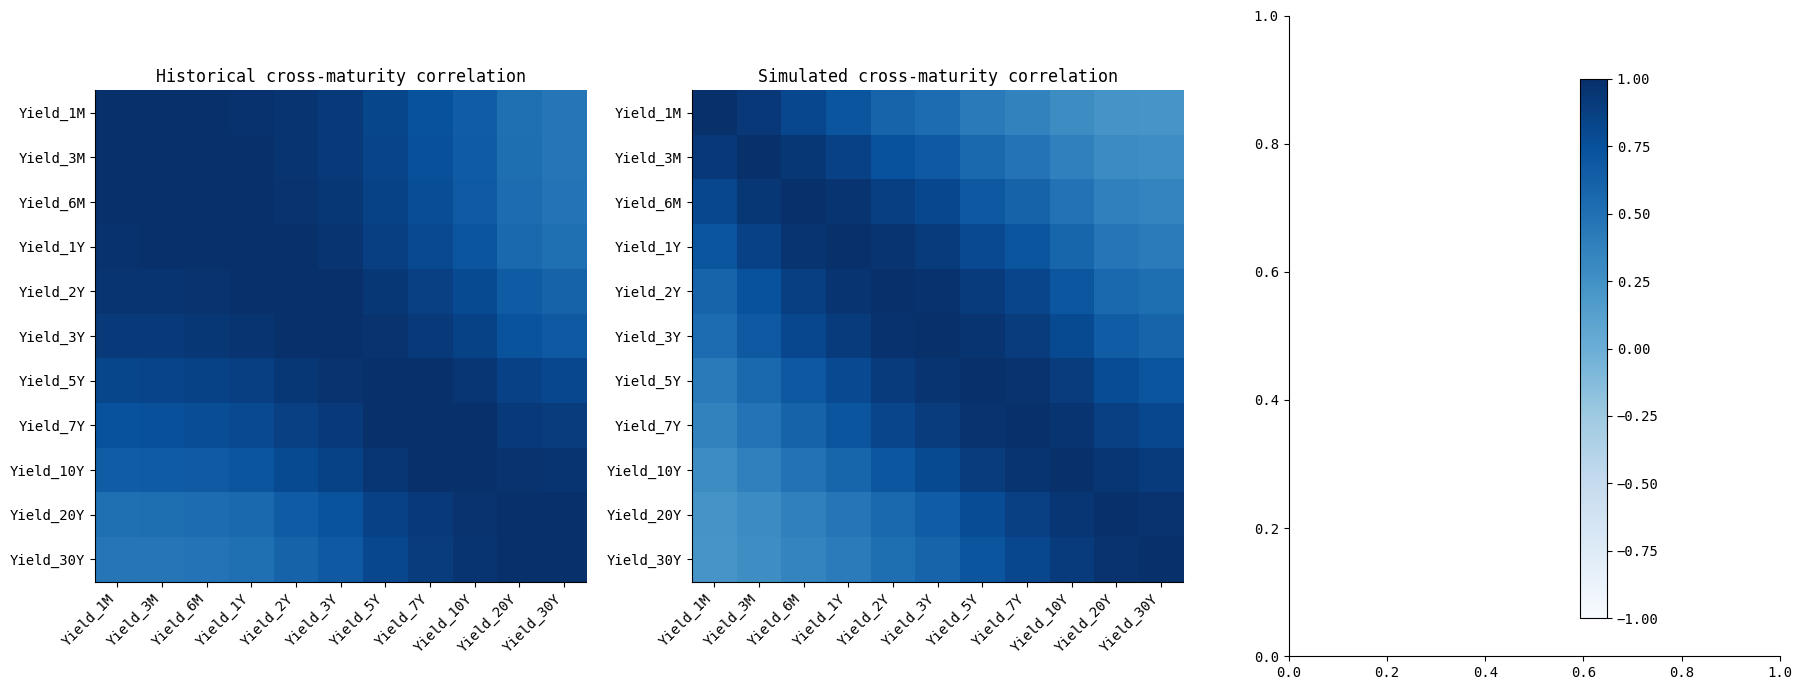

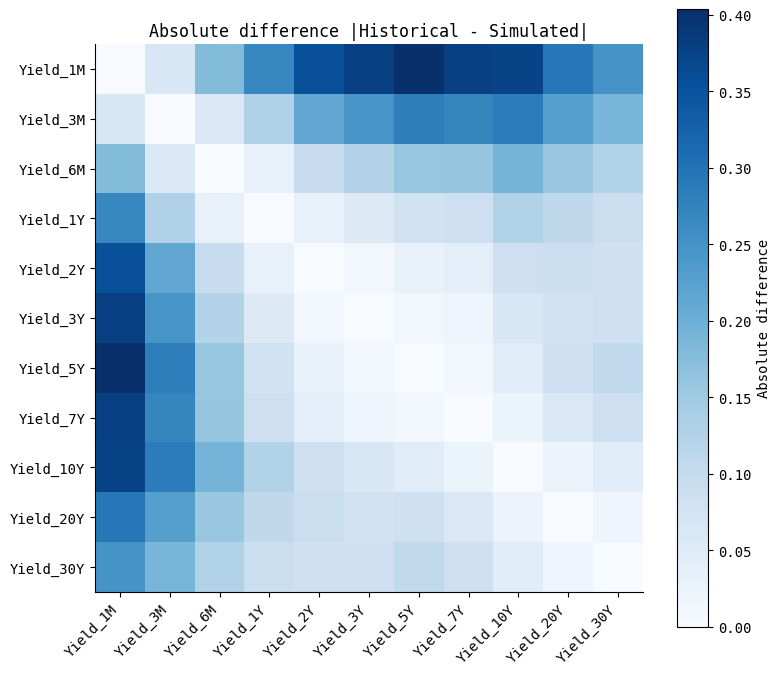

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================
historical_file = "historical data train.csv"
simulated_file = "mvp1_simulated_paths.csv"

# =========================
# Helper functions
# =========================
def plot_heatmap(ax, matrix, title, labels):
    im = ax.imshow(matrix.values, vmin=-1, vmax=1, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    return im

def clean_numeric_frame(df, columns):
    cleaned = df[columns].apply(pd.to_numeric, errors="coerce")
    cleaned = cleaned.dropna(how="any")
    return cleaned

# =========================
# Historical data: daily -> monthly
# Remove GDP, FED, and interest rate columns by keeping only yield columns
# =========================
hist_df = pd.read_csv(historical_file)
hist_df["DATE"] = pd.to_datetime(hist_df["DATE"])
hist_df = hist_df.sort_values("DATE").reset_index(drop=True)

hist_yield_cols = [c for c in hist_df.columns if c.startswith("Yield_")]
hist_monthly = hist_df[["DATE"] + hist_yield_cols].copy()
hist_monthly = hist_monthly.set_index("DATE").resample("M").last().reset_index()
hist_monthly = clean_numeric_frame(hist_monthly, hist_yield_cols)

corr_real = hist_monthly.corr()

# =========================
# Simulated data: pooled across all scenarios
# =========================
sim_df = pd.read_csv(simulated_file)
sim_yield_cols = [c for c in sim_df.columns if c.startswith("Y_")]
sim_yield_map = {c: c.replace("Y_", "Yield_") for c in sim_yield_cols}
sim_yields = clean_numeric_frame(sim_df, sim_yield_cols).rename(columns=sim_yield_map)
corr_gen = sim_yields.corr()

# Align matrices on common maturities
common_cols = corr_real.columns.intersection(corr_gen.columns)
if len(common_cols) == 0:
    raise ValueError("No shared maturity columns found between historical and simulated data.")
corr_real = corr_real.loc[common_cols, common_cols]
corr_gen = corr_gen.loc[common_cols, common_cols]

# =========================
# L1 norm between the two matrices
# =========================
l1 = np.abs(corr_real.values - corr_gen.values).sum()
print(f"Historical monthly matrix shape: {corr_real.shape}")
print(f"Simulated pooled matrix shape:  {corr_gen.shape}")
print(f"L1 norm between matrices: {l1:.6f}")

# =========================
# Heatmaps
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
im1 = plot_heatmap(axes[0], corr_real, "Historical cross-maturity correlation", list(common_cols))
im2 = plot_heatmap(axes[1], corr_gen, "Simulated cross-maturity correlation", list(common_cols))
fig.colorbar(im1, ax=axes, fraction=0.025, pad=0.04)
plt.tight_layout()
plt.show()

# Optional: absolute-difference heatmap
diff = (corr_real - corr_gen).abs()
plt.figure(figsize=(8, 7))
plt.imshow(diff.values, cmap="Blues")
plt.title("Absolute difference |Historical - Simulated|")
plt.xticks(range(len(common_cols)), common_cols, rotation=45, ha="right")
plt.yticks(range(len(common_cols)), common_cols)
plt.colorbar(label="Absolute difference")
plt.tight_layout()
plt.show()



using rolling windows and follows sig-wasserstein paper

Loading historical data …
  Monthly observations: 232  (2002-01 → 2021-04)

Computing historical cross-correlation matrices (window = 60 months, stride = 1) …
  Number of 5-year windows: 173
  Mean cross-correlation matrix shape: (11, 11)

Loading simulated paths …
  Scenarios: 200  |  Months per scenario: [60]
Computing simulated cross-correlation matrices …
  Mean cross-correlation matrix shape: (11, 11)

──────────────────────────────────────────────────
  L1 norm  Σ_i Σ_j |τ_real^ij - τ_sim^ij|  =  14.814595
  (d=11 maturities  →  121 matrix entries)
──────────────────────────────────────────────────


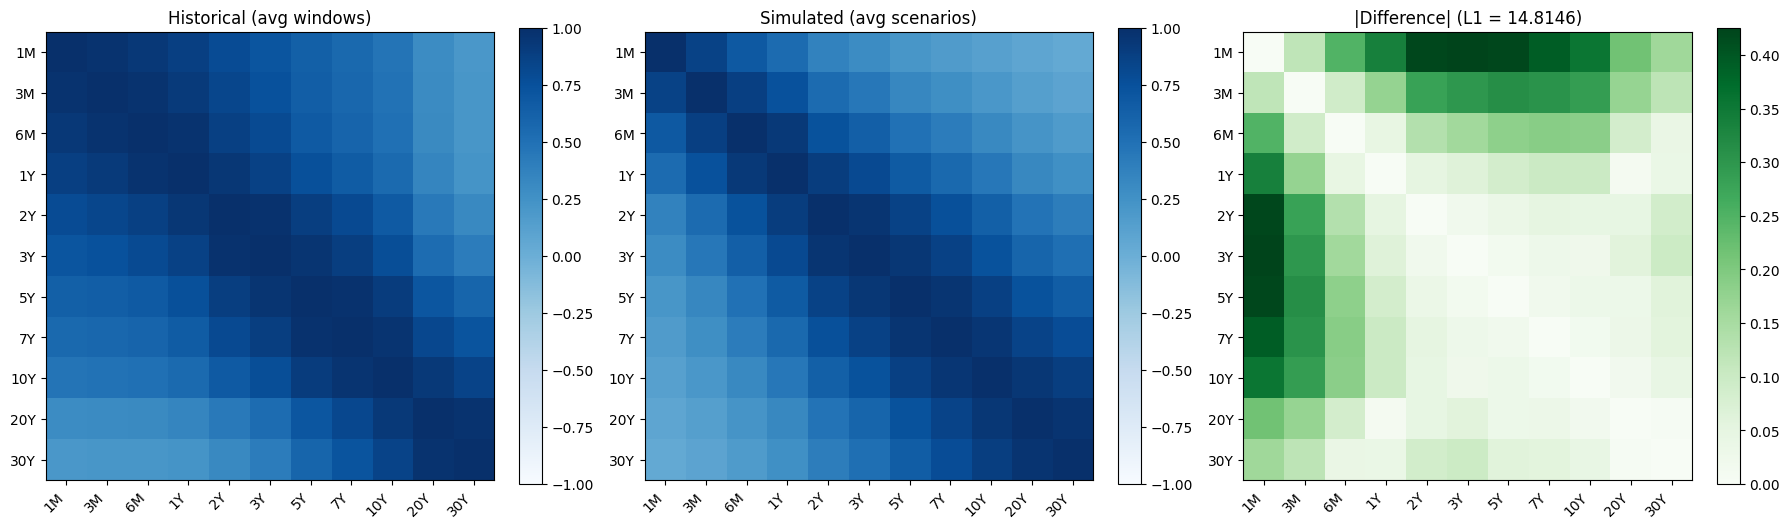


── Historical mean cross-correlation matrix ──
         1M      3M      6M      1Y      2Y      3Y      5Y      7Y     10Y     20Y     30Y
1M   1.0000  0.9695  0.9344  0.8822  0.7859  0.7165  0.6253  0.5548  0.4750  0.2906  0.2027
3M   0.9695  1.0000  0.9716  0.9192  0.8209  0.7457  0.6461  0.5707  0.4884  0.3004  0.2089
6M   0.9344  0.9716  1.0000  0.9694  0.8732  0.7902  0.6794  0.5963  0.5033  0.3059  0.2072
1Y   0.8822  0.9192  0.9694  1.0000  0.9422  0.8666  0.7511  0.6595  0.5493  0.3364  0.2275
2Y   0.7859  0.8209  0.8732  0.9422  1.0000  0.9770  0.8903  0.8000  0.6723  0.4365  0.3178
3Y   0.7165  0.7457  0.7902  0.8666  0.9770  1.0000  0.9585  0.8873  0.7668  0.5327  0.4107
5Y   0.6253  0.6461  0.6794  0.7511  0.8903  0.9585  1.0000  0.9788  0.9036  0.7066  0.5923
7Y   0.5548  0.5707  0.5963  0.6595  0.8000  0.8873  0.9788  1.0000  0.9679  0.8186  0.7196
10Y  0.4750  0.4884  0.5033  0.5493  0.6723  0.7668  0.9036  0.9679  1.0000  0.9229  0.8452
20Y  0.2906  0.3004  0.3059  0.3

In [30]:
"""
Cross-Maturity Correlation Analysis
Based on Liao et al. (2024) "Sig-Wasserstein GANs for conditional time series generation"
Cross-correlation metric: Appendix C, Equations (C.3) and (C.4)

L1 norm of real vs generated cross-correlation matrices:
    metric = sum_i sum_j |tau^{i,j}_r - tau^{i,j}_G|

where tau^{i,j} = cov^{i,j} / sqrt(cov^{i,i} * cov^{j,j})
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ─────────────────────────────────────────────
# 0. Configuration
# ─────────────────────────────────────────────
YIELD_COLS_HIST = [
    "Yield_1M", "Yield_3M", "Yield_6M", "Yield_1Y",
    "Yield_2Y", "Yield_3Y", "Yield_5Y", "Yield_7Y",
    "Yield_10Y", "Yield_20Y", "Yield_30Y"
]
YIELD_COLS_SIM = [
    "Y_1M", "Y_3M", "Y_6M", "Y_1Y",
    "Y_2Y", "Y_3Y", "Y_5Y", "Y_7Y",
    "Y_10Y", "Y_20Y", "Y_30Y"
]
MATURITY_LABELS = [
    "1M", "3M", "6M", "1Y",
    "2Y", "3Y", "5Y", "7Y",
    "10Y", "20Y", "30Y"
]
WINDOW_MONTHS = 60   # 5-year sliding window to match 60-month simulated paths

# ─────────────────────────────────────────────
# 1. Helper: cross-correlation matrix per Eq (C.3)
# ─────────────────────────────────────────────
def cross_corr_matrix(X: np.ndarray) -> np.ndarray:
    """
    X : (T, d) array of time series observations
    Returns (d, d) correlation matrix tau where
        tau^{i,j} = cov^{i,j} / sqrt(cov^{i,i} * cov^{j,j})
    using the unbiased sample estimator from paper Eq (C.3):
        cov^{i,j} = (1/T) sum_t X^i_t X^j_t - (1/T sum X^i)(1/T sum X^j)
    """
    T = X.shape[0]
    mean = X.mean(axis=0)                    # (d,)
    cov = (X.T @ X) / T - np.outer(mean, mean)   # (d, d)  -- Eq (C.3)
    std = np.sqrt(np.diag(cov))              # (d,)
    outer_std = np.outer(std, std)
    # avoid div/0
    corr = np.where(outer_std > 0, cov / outer_std, 0.0)
    return corr

# ─────────────────────────────────────────────
# 2. Load & pre-process historical data
# ─────────────────────────────────────────────
print("Loading historical data …")
hist = pd.read_csv("historical data train.csv")

# Remove GDP, Fed Funds and CPI columns; keep only yield curve
# GDP → Real_GDP | Fed → FedFunds | (CPI_Level implicitly removed)
hist = hist[["DATE"] + YIELD_COLS_HIST].copy()
hist["DATE"] = pd.to_datetime(hist["DATE"])
hist = hist.sort_values("DATE").reset_index(drop=True)

# Aggregate daily → monthly (end-of-month last observation)
hist["YearMonth"] = hist["DATE"].dt.to_period("M")
hist_monthly = (hist.groupby("YearMonth")[YIELD_COLS_HIST]
                .last()
                .reset_index())
hist_monthly = hist_monthly.sort_values("YearMonth").reset_index(drop=True)

n_months = len(hist_monthly)
print(f"  Monthly observations: {n_months}  "
      f"({hist_monthly['YearMonth'].iloc[0]} → {hist_monthly['YearMonth'].iloc[-1]})")

# ─────────────────────────────────────────────
# 3. Sliding-window cross-correlation matrices (historical)
# ─────────────────────────────────────────────
print(f"\nComputing historical cross-correlation matrices "
      f"(window = {WINDOW_MONTHS} months, stride = 1) …")

hist_values = hist_monthly[YIELD_COLS_HIST].values  # (n_months, 11)
n_windows = n_months - WINDOW_MONTHS + 1

hist_corr_matrices = []
for start in range(n_windows):
    window = hist_values[start : start + WINDOW_MONTHS]   # (60, 11)
    hist_corr_matrices.append(cross_corr_matrix(window))

hist_corr_matrices = np.array(hist_corr_matrices)   # (n_windows, 11, 11)
hist_mean_corr = hist_corr_matrices.mean(axis=0)    # average across windows

print(f"  Number of 5-year windows: {n_windows}")
print(f"  Mean cross-correlation matrix shape: {hist_mean_corr.shape}")

# ─────────────────────────────────────────────
# 4. Load & process simulated data
# ─────────────────────────────────────────────
print("\nLoading simulated paths …")
sim = pd.read_csv("mvp1_simulated_paths.csv")
scenarios = sim["Scenario_ID"].unique()
n_scenarios = len(scenarios)
months_per_scenario = sim.groupby("Scenario_ID")["Month"].count().unique()
print(f"  Scenarios: {n_scenarios}  |  Months per scenario: {months_per_scenario}")

# Per paper Eq (C.4): compute cov matrix per scenario, then average
print("Computing simulated cross-correlation matrices …")
sim_corr_matrices = []
for sc_id in scenarios:
    sc_data = sim[sim["Scenario_ID"] == sc_id][YIELD_COLS_SIM].values  # (60, 11)
    sim_corr_matrices.append(cross_corr_matrix(sc_data))

sim_corr_matrices = np.array(sim_corr_matrices)     # (n_scenarios, 11, 11)
sim_mean_corr = sim_corr_matrices.mean(axis=0)       # average across scenarios

print(f"  Mean cross-correlation matrix shape: {sim_mean_corr.shape}")

# ─────────────────────────────────────────────
# 5. L1 norm  (paper Section 6, Feature dependency metric)
# ─────────────────────────────────────────────
diff_matrix = np.abs(hist_mean_corr - sim_mean_corr)
l1_norm = diff_matrix.sum()

print(f"\n{'─'*50}")
print(f"  L1 norm  Σ_i Σ_j |τ_real^ij - τ_sim^ij|  =  {l1_norm:.6f}")
print(f"  (d={len(MATURITY_LABELS)} maturities  →  {len(MATURITY_LABELS)**2} matrix entries)")
print(f"{'─'*50}")

# ─────────────────────────────────────────────
# 6. Visualisation (clean white style)
# ─────────────────────────────────────────────
plt.style.use("default")  # reset to standard white theme

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Historical
im0 = axes[0].imshow(hist_mean_corr, cmap="Blues", vmin=-1, vmax=1)
axes[0].set_title("Historical (avg windows)")

# Simulated
im1 = axes[1].imshow(sim_mean_corr, cmap="Blues", vmin=-1, vmax=1)
axes[1].set_title("Simulated (avg scenarios)")

# Difference
im2 = axes[2].imshow(diff_matrix, cmap="Greens")
axes[2].set_title(f"|Difference| (L1 = {l1_norm:.4f})")

# Axis labels
for ax in axes:
    ax.set_xticks(range(len(MATURITY_LABELS)))
    ax.set_yticks(range(len(MATURITY_LABELS)))
    ax.set_xticklabels(MATURITY_LABELS, rotation=45, ha="right")
    ax.set_yticklabels(MATURITY_LABELS)

# Colorbars
fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 8. Print summary table
# ─────────────────────────────────────────────
print("\n── Historical mean cross-correlation matrix ──")
df_hist = pd.DataFrame(hist_mean_corr, index=MATURITY_LABELS, columns=MATURITY_LABELS)
print(df_hist.round(4).to_string())

print("\n── Simulated mean cross-correlation matrix ──")
df_sim = pd.DataFrame(sim_mean_corr, index=MATURITY_LABELS, columns=MATURITY_LABELS)
print(df_sim.round(4).to_string())

print("\n── |Difference| matrix ──")
df_diff = pd.DataFrame(diff_matrix, index=MATURITY_LABELS, columns=MATURITY_LABELS)
print(df_diff.round(4).to_string())

print(f"\n{'═'*50}")
print(f"  FINAL  L¹ norm = {l1_norm:.6f}")
print(f"{'═'*50}")
print("\nDone.")
